# 01 - EDA: Heart Disease Dataset

This notebook performs exploratory data analysis on the UCI Heart Disease dataset.
The notebook focuses on data loading, target creation, missing value analysis, categorical analysis, numerical analysis, and dataset bias notes.


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.options.display.max_columns = 100
pd.options.display.max_rows = 200

base_path = Path.cwd()
candidate_paths = [
    base_path / ".." / "data" / "raw" / "heart_disease_uci.csv",
    base_path / "data" / "raw" / "heart_disease_uci.csv",
]
data_path = next((p for p in candidate_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError(
        f"Data file not found. Checked: {candidate_paths}. Please place the UCI heart disease CSV in data/raw."
    )

df = pd.read_csv(data_path)
print(f"Loaded data from {data_path} with shape {df.shape}")
print()
print("Columns:")
print(df.columns.tolist())


Loaded data from d:\代码集\Python\heart-disease-lightgbm\notebooks\..\data\raw\heart_disease_uci.csv with shape (920, 16)

Columns:
['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']


## 1. Target creation

The original label column is `num`, which represents disease severity.
A binary target is created from `num` as:
`target = 1 if num > 0 else 0`.
This notebook keeps `num` for explanation and uses `target` for all binary analysis.


In [2]:
if "num" not in df.columns:
    raise KeyError("The dataset does not contain the original num column.")

df["target"] = (df["num"] > 0).astype(int)
print("Created binary target column.")
print(df[["num", "target"]].head())


Created binary target column.
   num  target
0    0       0
1    2       1
2    1       1
3    0       0
4    0       0


## 2. Basic dataset information

Review the dataset shape, first rows, data types, and summary statistics.


In [3]:
print("Shape:")
print(df.shape)
print()
print("Head:")
print(df.head())
print()
print("Info:")
df.info()
print()
print("Describe (all):")
print(df.describe(include="all"))
print()
print("Data types:")
print(df.dtypes)
print()
print("Unique value counts:")
print(df.nunique())


Shape:
(920, 17)

Head:
   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  target  
0       fixed defect    0       0  
1             normal    2       1  
2  reversable defect    1       1  
3       

## 3. Missing value analysis

Compute missing value counts and percentages, sorted by the highest missing rate.
Today we only observe missing values and do not impute them.


In [4]:
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": df.isnull().mean() * 100
}).sort_values("missing_percentage", ascending=False)
missing_summary


,missing_count,missing_percentage
ca,611,66.413043
thal,486,52.826087
slope,309,33.586957
fbs,90,9.782609
oldpeak,62,6.739130
trestbps,59,6.413043
exang,55,5.978261
thalch,55,5.978261
chol,30,3.260870
restecg,2,0.217391


The missing value summary shows which variables have the highest missing rates.
If `ca`, `thal`, or `slope` have significant missing rates, they should be handled carefully in preprocessing.
Today we do not fill any missing values.


## 4. Categorical variable analysis

The following columns are treated as categorical features.


In [5]:
categorical_cols = [
    "sex", "dataset", "cp", "fbs", "restecg",
    "exang", "slope", "thal"
]

for col in categorical_cols:
    print(f"=== {col} ===")
    print("Counts:")
    print(df[col].value_counts(dropna=False))
    print()
    print("Percentages:")
    print(df[col].value_counts(normalize=True, dropna=False).mul(100).round(2))
    print()


=== sex ===
Counts:
sex
Male      726
Female    194
Name: count, dtype: int64

Percentages:
sex
Male      78.91
Female    21.09
Name: proportion, dtype: float64

=== dataset ===
Counts:
dataset
Cleveland        304
Hungary          293
VA Long Beach    200
Switzerland      123
Name: count, dtype: int64

Percentages:
dataset
Cleveland        33.04
Hungary          31.85
VA Long Beach    21.74
Switzerland      13.37
Name: proportion, dtype: float64

=== cp ===
Counts:
cp
asymptomatic       496
non-anginal        204
atypical angina    174
typical angina      46
Name: count, dtype: int64

Percentages:
cp
asymptomatic       53.91
non-anginal        22.17
atypical angina    18.91
typical angina      5.00
Name: proportion, dtype: float64

=== fbs ===
Counts:
fbs
False    692
True     138
NaN       90
Name: count, dtype: int64

Percentages:
fbs
False    75.22
True     15.00
NaN       9.78
Name: proportion, dtype: float64

=== restecg ===
Counts:
restecg
normal              551
lv hypertrophy 

These categorical columns include both encoded integer features and string categories.
They should be treated as categorical features in later preprocessing.


## 5. Categorical variables vs target

Analyze how each categorical feature relates to the binary target.


=== sex vs target ===
target         0         1
sex                       
Female  0.742268  0.257732
Male    0.367769  0.632231



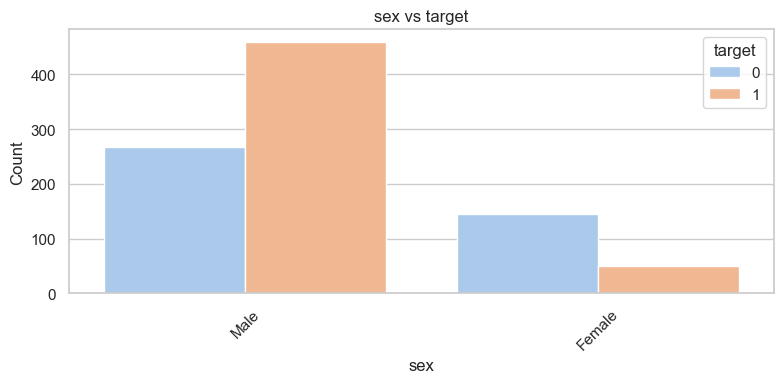


=== dataset vs target ===
target                0         1
dataset                          
Cleveland      0.542763  0.457237
Hungary        0.638225  0.361775
Switzerland    0.065041  0.934959
VA Long Beach  0.255000  0.745000



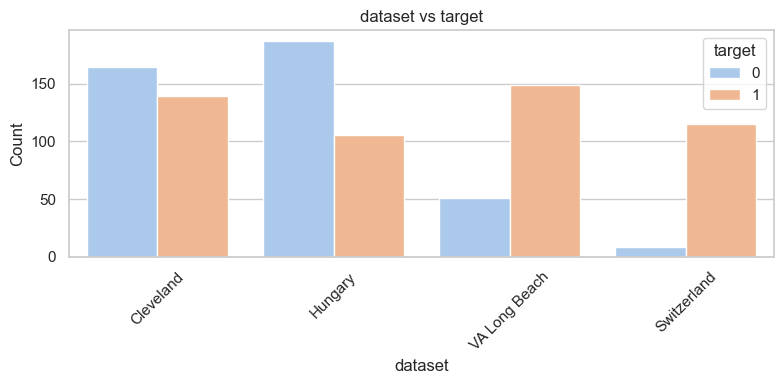


=== cp vs target ===
target                  0         1
cp                                 
asymptomatic     0.209677  0.790323
atypical angina  0.862069  0.137931
non-anginal      0.642157  0.357843
typical angina   0.565217  0.434783



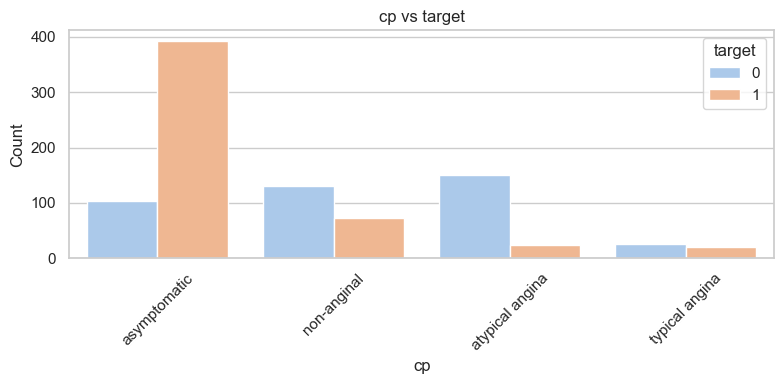


=== fbs vs target ===
target          0         1
fbs                        
False    0.510116  0.489884
True     0.318841  0.681159
Missing  0.155556  0.844444



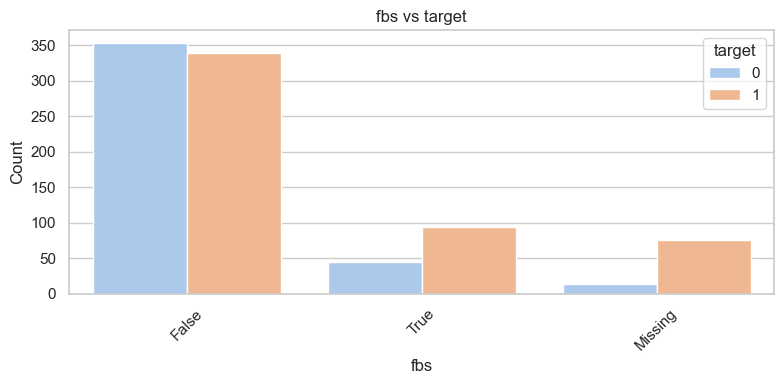


=== restecg vs target ===
target                   0         1
restecg                             
Missing           0.000000  1.000000
lv hypertrophy    0.436170  0.563830
normal            0.486388  0.513612
st-t abnormality  0.340782  0.659218



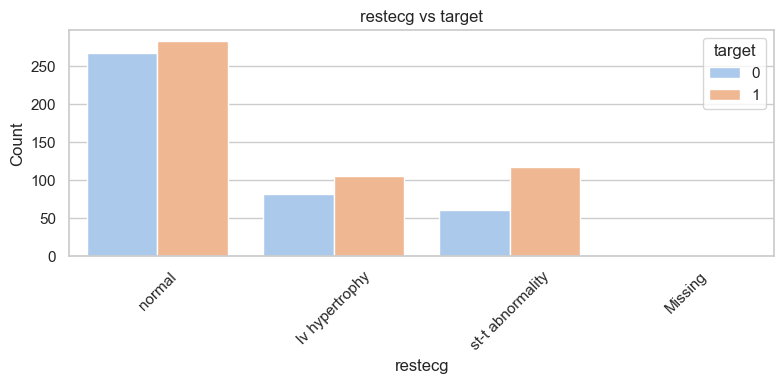


=== exang vs target ===
target          0         1
exang                      
False    0.636364  0.363636
True     0.163205  0.836795
Missing  0.363636  0.636364



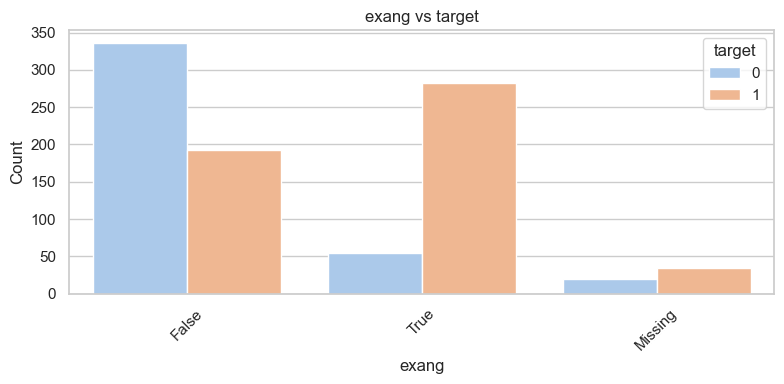


=== slope vs target ===
target              0         1
slope                          
Missing      0.624595  0.375405
downsloping  0.222222  0.777778
flat         0.228986  0.771014
upsloping    0.615764  0.384236



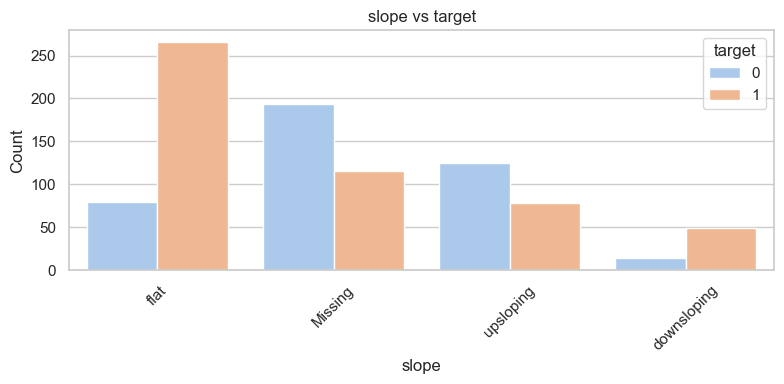


=== thal vs target ===
target                    0         1
thal                                 
Missing            0.460905  0.539095
fixed defect       0.239130  0.760870
normal             0.704082  0.295918
reversable defect  0.197917  0.802083



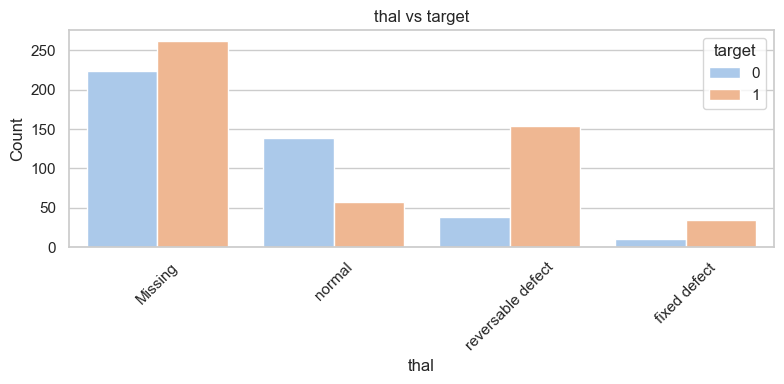

In [6]:
for col in categorical_cols:
    print(f"=== {col} vs target ===")
    ctab = pd.crosstab(df[col].fillna("Missing"), df["target"], normalize="index")
    print(ctab)
    print()

    plot_data = df.copy()
    plot_data[col] = plot_data[col].fillna("Missing")
    plt.figure(figsize=(8, 4))
    sns.countplot(x=col, hue="target", data=plot_data, palette="pastel", order=plot_data[col].value_counts().index)
    plt.title(f"{col} vs target")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    print()


## 6. Numerical variables and target

Analyze the relationship between numerical features and the binary target using boxplots and histograms.


C:\Users\ASUS\AppData\Local\Temp\ipykernel_22652\1498798588.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="target", y=col, data=df, palette="pastel")


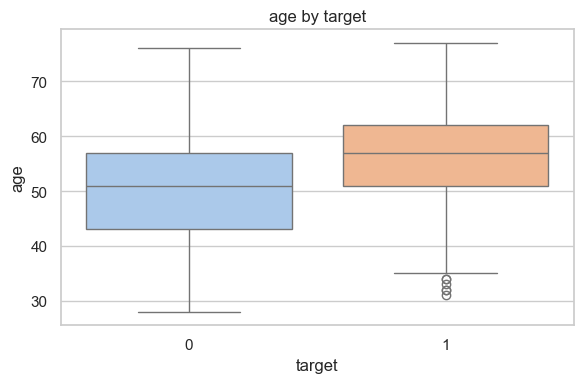

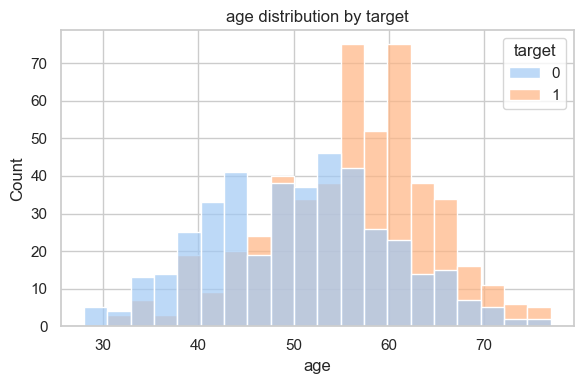

C:\Users\ASUS\AppData\Local\Temp\ipykernel_22652\1498798588.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="target", y=col, data=df, palette="pastel")


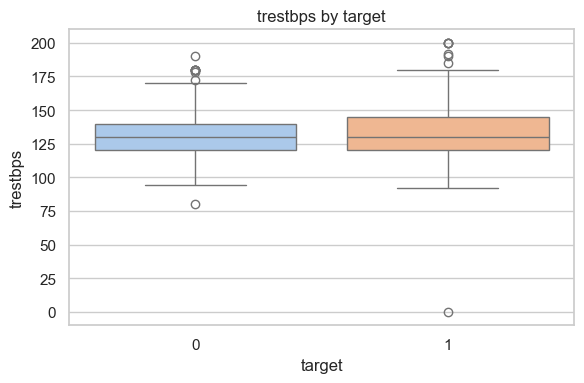

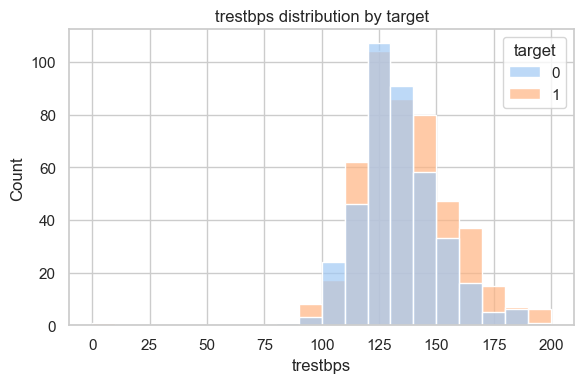

C:\Users\ASUS\AppData\Local\Temp\ipykernel_22652\1498798588.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="target", y=col, data=df, palette="pastel")


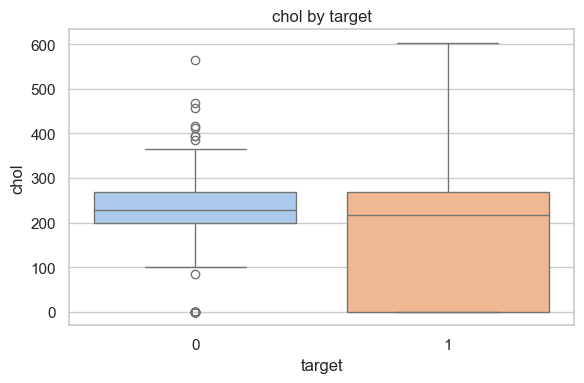

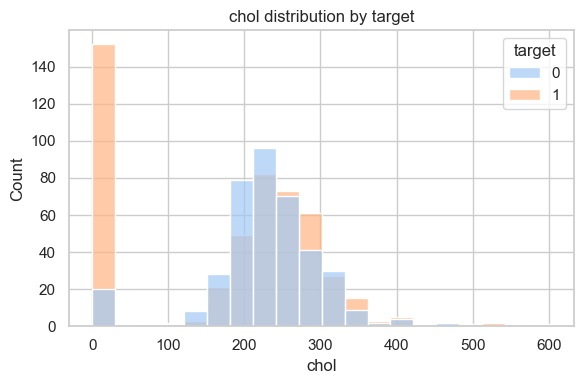

C:\Users\ASUS\AppData\Local\Temp\ipykernel_22652\1498798588.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="target", y=col, data=df, palette="pastel")


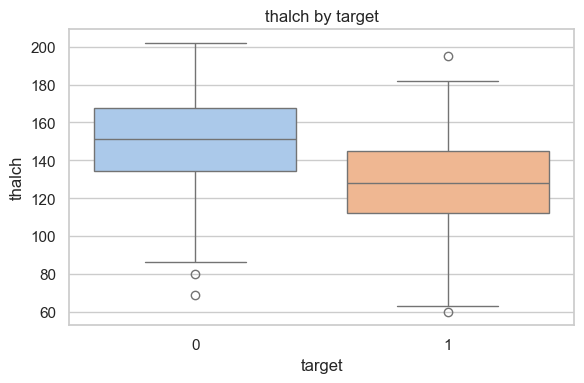

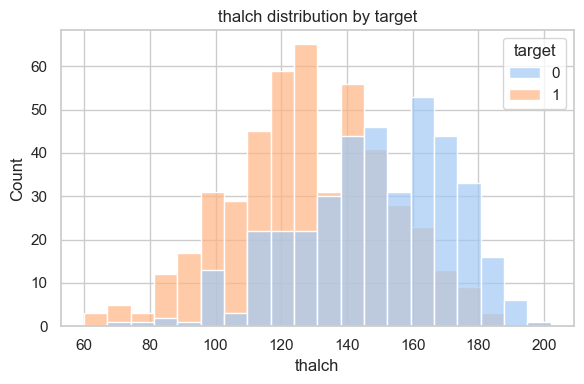

C:\Users\ASUS\AppData\Local\Temp\ipykernel_22652\1498798588.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="target", y=col, data=df, palette="pastel")


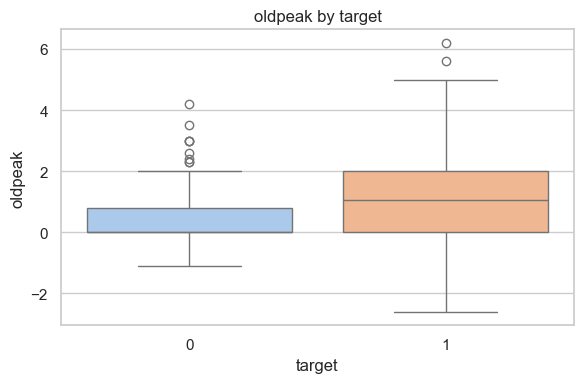

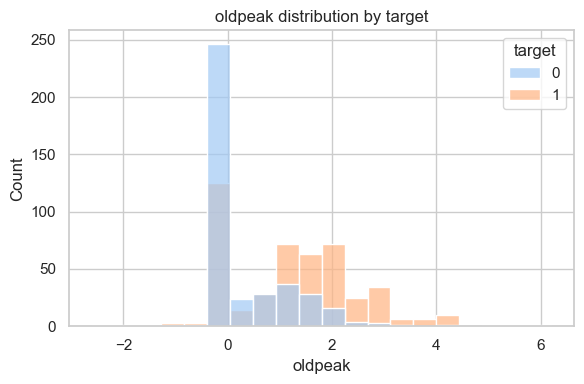

In [7]:
numeric_cols = ["age", "trestbps", "chol", "thalch", "oldpeak"]
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x="target", y=col, data=df, palette="pastel")
    plt.title(f"{col} by target")
    plt.xlabel("target")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 4))
    sns.histplot(data=df, x=col, hue="target", bins=20, palette="pastel", alpha=0.7, kde=False)
    plt.title(f"{col} distribution by target")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()
    print()


## 7. Correlation heatmap

Compute correlations for numeric columns only. Non-numeric columns are excluded to avoid errors.


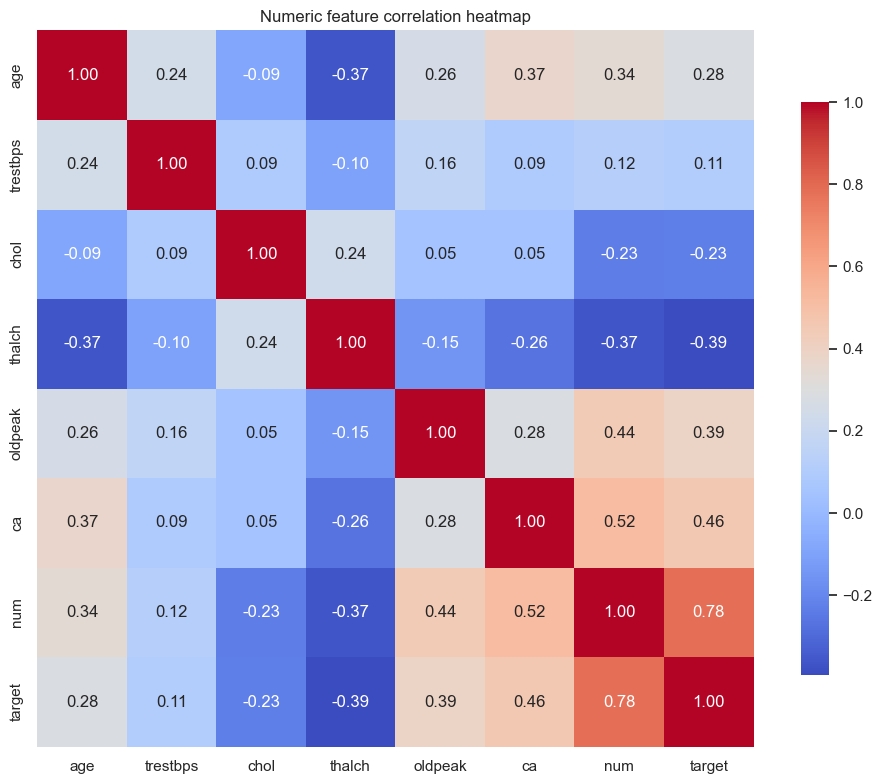

In [8]:
numeric_cols = [col for col in df.select_dtypes(include=["number"]).columns if col != "id"]
corr = df[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={"shrink": 0.8})
plt.title("Numeric feature correlation heatmap")
plt.tight_layout()
plt.show()


## 8. Dataset source analysis

The `dataset` column indicates the source of each sample. This may introduce dataset bias and should be handled carefully in modeling.


In [9]:
print("Dataset counts:")
print(df["dataset"].value_counts(dropna=False))
print()
print("Dataset vs target crosstab (normalized by row):")
print(pd.crosstab(df["dataset"].fillna("Missing"), df["target"], normalize="index"))


Dataset counts:
dataset
Cleveland        304
Hungary          293
VA Long Beach    200
Switzerland      123
Name: count, dtype: int64

Dataset vs target crosstab (normalized by row):
target                0         1
dataset                          
Cleveland      0.542763  0.457237
Hungary        0.638225  0.361775
Switzerland    0.065041  0.934959
VA Long Beach  0.255000  0.745000


Because `dataset` represents the sample source, it may introduce dataset-specific bias.
In later steps, we should decide whether to drop it, encode it carefully, or use source-aware validation.


## 9. EDA Summary

- The dataset contains patient information and a `num` label representing disease severity.
- A binary `target` label is created from `num`: `target = 1 if num > 0 else 0`.
- `target` is used for all binary EDA in this notebook.
- Check whether `target` is roughly balanced from the counts above.
- Missing value analysis highlights variables that need careful preprocessing, especially `ca`, `thal`, and `slope` if their missing rate is high.
- Categorical features are: `sex`, `dataset`, `cp`, `fbs`, `restecg`, `exang`, `slope`, `thal`.
- Numerical features analyzed are: `age`, `trestbps`, `chol`, `thalch`, `oldpeak`.
- `dataset` may introduce dataset bias, so use it carefully in modeling.
- The next step is preprocessing, not modeling.
